# Chapter 15: Dynamic Programming for Consumption and Saving

*The Bellman Equation*

> *"The essential property of dynamic programming is that it turns a multi-period optimization into a sequence of single-period optimizations, each solved analytically or numerically."*
> — Richard Bellman, *Dynamic Programming*, 1957

**Cross-reference:** *Principles* Ch. 11 (consumption theory: LCH, PIH, Euler equation, buffer-stock); Ch. 11.5 (buffer-stock saving and precautionary motive) **[P:Ch.11, P:Ch.11.5]**

---

## 15.1 The Principle of Optimality

Chapter 11 solved the RCK model by the Hamiltonian method — a technique that works elegantly in continuous time when the state space is low-dimensional. In discrete time, with multiple state variables, stochastic shocks, and binding inequality constraints, the **Bellman approach** is the standard tool.

The key insight is **Bellman's principle of optimality** (Bellman, 1957):

> **"An optimal policy has the property that whatever the initial state and initial decision are, the remaining decisions must constitute an optimal policy with regard to the state resulting from the first decision."**

In other words: if you are following an optimal plan, then the continuation of that plan from any future date onward must also be optimal, given the state you have reached. This recursive structure converts an infinite-sequence optimization into a functional equation — the **Bellman equation** — that characterizes the value function.

### 15.1.1 The Finite-Horizon Case

Consider a $T$-period consumption-saving problem. The household maximizes:

$$\sum_{t=0}^{T-1}\beta^t u(c_t), \quad \text{s.t.} \quad a_{t+1} = (1+r)(a_t - c_t), \quad c_t \geq 0, \quad a_T \geq 0.$$

**Definition 15.1 (Value Function — Finite Horizon).** The **value function** $V_t(a)$ is the maximum utility achievable from period $t$ onward, given wealth $a$ at the start of period $t$:

$$V_t(a) = \max_{\{c_s\}_{s=t}^{T-1}} \sum_{s=t}^{T-1}\beta^{s-t}u(c_s).$$

By the principle of optimality, $V_t$ satisfies the **Bellman equation**:

$$V_t(a) = \max_{0 \leq c \leq a}\left\{u(c) + \beta V_{t+1}\bigl((1+r)(a-c)\bigr)\right\}, \quad t = 0, 1, \ldots, T-1,$$

with terminal condition $V_T(a) = 0$ (no utility after period $T$; the terminal wealth constraint $a_T \geq 0$ is imposed as a feasibility condition).

**Algorithm (Backward Induction):**
1. Set $V_T(a) = 0$ for all $a$.
2. For $t = T-1, T-2, \ldots, 0$: solve the one-period maximization problem and store the optimal policy $c_t^*(a)$ and updated value $V_t(a)$.

This backward recursion is feasible because period-$t$ optimization only requires $V_{t+1}$ (already computed).

### 15.1.2 The Infinite-Horizon Case

For the infinite-horizon stationary problem $\max_{\{c_t\}}\sum_{t=0}^\infty\beta^t u(c_t)$ with constant return $r$ and the same feasibility constraints, the value function is **time-stationary**: $V_t(a) = V(a)$ for all $t$.

**Definition 15.2 (Stationary Bellman Equation).** The **stationary Bellman equation** is:

$$\boxed{V(a) = \max_{0 \leq c \leq a}\left\{u(c) + \beta V\bigl((1+r)(a-c)\bigr)\right\}.}$$

This is a functional equation in the unknown function $V: \mathbb{R}_+ \to \mathbb{R}$. We need to show that it has a unique solution and provide a computational method to find it.

---

## 15.2 The Bellman Operator and the Contraction Mapping Theorem

**Definition 15.3 (Bellman Operator).** Define the **Bellman operator** $\mathcal{T}$ acting on bounded functions $V: \mathbb{R}_+ \to \mathbb{R}$ by:

$$(\mathcal{T}V)(a) \equiv \max_{0 \leq c \leq a}\left\{u(c) + \beta V\bigl((1+r)(a-c)\bigr)\right\}.$$

The stationary Bellman equation is the fixed-point equation $V = \mathcal{T}V$.

**Theorem 15.1 (Blackwell's Sufficient Conditions for Contraction).** The operator $\mathcal{T}$ is a contraction with modulus $\beta$ on the space $\mathcal{C}_b(\mathbb{R}_+)$ of bounded continuous functions, provided:

1. **(Monotonicity):** If $V \leq W$ pointwise, then $\mathcal{T}V \leq \mathcal{T}W$.
2. **(Discounting):** For any constant $a \geq 0$ and scalar $\lambda \geq 0$: $\mathcal{T}(V + \lambda) \leq \mathcal{T}V + \beta\lambda$.

**Theorem 15.2 (Banach Contraction Mapping Theorem).** Let $(\mathcal{X}, d)$ be a complete metric space and $\mathcal{T}: \mathcal{X} \to \mathcal{X}$ a contraction with modulus $\beta \in [0,1)$. Then:

1. $\mathcal{T}$ has a **unique fixed point** $V^* \in \mathcal{X}$.
2. For any $V_0 \in \mathcal{X}$, the sequence $V_{n+1} = \mathcal{T}V_n$ converges to $V^*$ with error bound $d(V_n, V^*) \leq \beta^n/(1-\beta)\cdot d(V_1, V_0)$.

*Proof sketch.* $\mathcal{T}$ is a contraction: $\|\mathcal{T}V - \mathcal{T}W\|_\infty \leq \beta\|V - W\|_\infty$. The sequence $V_n = \mathcal{T}^n V_0$ is Cauchy (distances decrease geometrically), hence convergent in the complete space $\mathcal{C}_b$. The limit $V^*$ satisfies $\mathcal{T}V^* = V^*$ (take limits through the contraction). Uniqueness: if $\mathcal{T}V^* = V^*$ and $\mathcal{T}W^* = W^*$, then $\|V^*-W^*\|_\infty = \|\mathcal{T}V^*-\mathcal{T}W^*\|_\infty \leq \beta\|V^*-W^*\|_\infty$, which requires $V^* = W^*$. $\square$

*Economic significance.* The theorem guarantees that **value function iteration (VFI)** — repeatedly applying $\mathcal{T}$ to any initial guess $V_0$ — always converges to the true value function $V^*$, regardless of the starting point. The convergence rate is governed by $\beta$: with $\beta = 0.99$, convergence to 6-digit accuracy requires approximately $\log(10^{-6})/\log(0.99) \approx 1380$ iterations. In practice, the algorithm terminates in far fewer iterations because the sup-norm criterion is conservative.

---

## 15.3 Value Function Iteration (VFI)

### 15.3.1 Discretization

The continuous state $a$ is approximated by a finite grid $\mathcal{A} = \{a_1, a_2, \ldots, a_N\}$ with $a_1 = 0$ and $a_N = \bar{a}$ (the borrowing limit and maximum wealth). The value function $V$ is represented as a vector $\mathbf{V} = (V(a_1), \ldots, V(a_N))'$.

For each grid point $a_i$, the feasible consumption set is $\{c : 0 \leq c \leq a_i, (1+r)(a_i-c) \in \mathcal{A}\}$. In practice, we allow interpolation so that the next-period wealth $(1+r)(a_i-c)$ need not lie exactly on the grid.

**Algorithm 15.1 (Value Function Iteration).**

**Inputs:** Utility function $u$, discount factor $\beta$, return $r$, grid $\mathcal{A}$, initial guess $\mathbf{V}^0$, tolerance $\varepsilon$.

1. Set $n = 0$.
2. **Inner loop (Bellman operator):** For each $i = 1, \ldots, N$:
   - Form the payoff vector for all feasible $c_j \leq a_i$: $\Pi_{ij} = u(c_j) + \beta V^n((1+r)(a_i-c_j))$.
   - Set $V^{n+1}(a_i) = \max_j \Pi_{ij}$ and record the optimal policy $c^*(a_i) = c_{j^*}$.
3. **Check convergence:** if $\|\mathbf{V}^{n+1} - \mathbf{V}^n\|_\infty < \varepsilon$: stop.
4. Else: $n \leftarrow n+1$; go to step 2.

**Output:** $\mathbf{V}^* \approx \mathbf{V}^n$ (the value function) and $c^*(\cdot)$ (the policy function).

### 15.3.2 APL Implementation: The Bellman Operator in One Expression

The power of APL for VFI lies in expressing the inner loop (step 2) as a single array operation:

```apl
⎕IO←0 ⋄ ⎕ML←1

⍝ 1. Parameters
beta ← 0.96  ⋄  r ← 0.04  ⋄  N ← 200
a_grid ← (⍳N) × 10 ÷ N - 1

⍝ 2. State and Choice Grids as Flat Matrices
⍝ C_MAT columns vary (Choices), A_MAT rows vary (States)
C_MAT ← N N ⍴ a_grid
A_MAT ← ⍉ N N ⍴ a_grid

⍝ 3. Feasibility and Utility (Bounded at 1e¯10 to prevent DOMAIN ERROR)
feasible ← A_MAT ≥ C_MAT
u_c ← ⍟ 1e¯10 ⌈ C_MAT         
u_mat ← (u_c × feasible) + ¯1e20 × ~feasible

⍝ 4. Savings transition matrix: a' = (1+r)(a - c)
savings_mat ← (1 + r) × A_MAT - C_MAT

⍝ 5. Vectorized 1D Interpolation
⍝ Since a_grid is global, we only need to pass V (as ⍺) and x (as ⍵)
interp1d ← {
    V ← ⍺ ⋄ x ← ⍵
    idx ← 0 ⌈ (N - 2) ⌊ ⌊ (x - a_grid[0]) × (N - 1) ÷ a_grid[N - 1] - a_grid[0]
    w ← (x - a_grid[idx]) ÷ (a_grid[idx + 1] - a_grid[idx])
    
    ⍝ FIXED: Enforced standard math precedence for the weighted average
    ((1 - w) × V[idx]) + w × V[idx + 1]
}

⍝ 6. Bellman Operator
bellman ← {
    V_in ← ⍵
    V_next ← V_in interp1d savings_mat
    payoff ← u_mat + beta × V_next
    
    ⍝ FIXED: ⌈/ reduces over columns to find the max choice for each state
    ⌈/ payoff
}

⍝ 7. VFI Main Loop
V ← N ⍴ 0
tol ← 1e¯6
converged ← {tol > ⌈/ | ⍺ - ⍵}

⍝ Iterate until convergence
V_star ← bellman ⍣ converged ⊢ V

⍝ 8. Format Output
'--- VFI Convergence Complete ---'
'Value Function V(a) for the first 5 asset states:'
↑ (⍕¨ 5 ↑ a_grid) ,¨ (⊂' : ') ,¨ ⍕¨ 4 ⍕¨ 5 ↑ V_star
```

**Key APL idioms:**
- `a_grid ∘.≥ c_grid` — outer product of inequality: the $N\times N$ feasibility matrix.
- `⌈⌿ payoff` — column-wise maximum: the Bellman operator maximum over consumption choices.
- `bellman ⍣ converged ⊢ V` — apply `bellman` until the convergence predicate `converged` is satisfied.

In production code, the interpolation step should use APL's `⎕PY` to call scipy's interpolation, or implement a vectorized binary search using APL's `⍸` (interval index) primitive.

---

## 15.4 Policy Function Iteration: The Howard Improvement Algorithm

VFI converges at rate $\beta$ per iteration. For $\beta = 0.99$, this means thousands of iterations. **Policy function iteration (PFI)**, also known as the **Howard improvement algorithm**, converges much faster — often in 10–20 iterations.

**Algorithm 15.2 (Howard Policy Improvement).**

1. Start with an initial policy $c^0(a)$ (e.g., $c^0(a) = 0.9a$).
2. **Policy evaluation:** Find the value function $V^n$ corresponding to policy $c^n$ by solving the linear system $(I - \beta P_{c^n})V^n = u_{c^n}$, where $P_{c^n}$ is the transition matrix induced by policy $c^n$ and $u_{c^n}$ is the utility vector.
3. **Policy improvement:** For each $a_i$:
   $$c^{n+1}(a_i) = \arg\max_{0 \leq c \leq a_i}\left\{u(c) + \beta V^n\bigl((1+r)(a_i-c)\bigr)\right\}.$$
4. **Check convergence:** if $c^{n+1} = c^n$ everywhere: stop.
5. Else: $n \leftarrow n+1$; go to step 2.

**Why is PFI faster?** The policy evaluation step (2) solves a linear system $(I-\beta P)V = u$, which is equivalent to running VFI to full convergence with a fixed policy. This is much cheaper than one Bellman iteration (which evaluates the max over all policies) but moves the value function much further toward convergence. The policy improvement step (3) then updates the policy to be greedy with respect to the improved value function.

**Theorem 15.3 (Convergence of PFI).** Under the same conditions as Theorem 15.2, the Howard policy improvement algorithm converges in finite steps to the optimal policy $c^*$.

---

## 15.5 The Stochastic Bellman Equation

Most macroeconomic dynamic programming problems involve stochastic income or productivity shocks. The key modification to the Bellman equation is adding an expectation operator.

**Definition 15.4 (Stochastic Bellman Equation).** With i.i.d. income shock $y_t \sim F_y$ and state $(a_t, y_t)$:

$$V(a, y) = \max_{0 \leq c \leq a+y}\left\{u(c) + \beta\mathbb{E}_{y'}\bigl[V\bigl((1+r)(a+y-c), y'\bigr)\bigr]\right\}.$$

For a discrete income process with $S$ states and transition matrix $\Pi$ (so $\Pi_{ij} = P(y_{t+1} = y_j | y_t = y_i)$), the expected continuation value:

$$\mathbb{E}[V(a', y') | y_i] = \sum_{j=1}^S \Pi_{ij}V(a', y_j).$$

With the income process discretized to $S$ states and wealth grid of $N$ points, the state space has $N \times S$ points. The value function is an $N\times S$ matrix; the Bellman operator involves:

$$V^{n+1}(a_i, y_j) = \max_{c \leq a_i+y_j}\left\{u(c) + \beta\sum_k \Pi_{jk}V^n\bigl((1+r)(a_i+y_j-c), y_k\bigr)\right\}.$$

The inner maximization is still the expensive step, but now the continuation value involves a matrix multiplication $\Pi V^n$ which in APL is a single `+.×` operation.

---

## 15.6 Worked Example: The Buffer-Stock Consumption Model

*Cross-reference: Principles Ch. 11.5 (buffer-stock saving, Deaton 1991, Carroll 1997)* **[P:Ch.11.5]**

The buffer-stock model features an impatient household ($\beta < 1/(1+r)$) facing idiosyncratic income uncertainty and a borrowing constraint. The household saves not for retirement but as a precautionary buffer against income declines.

**Setup:**

- Income: $y_t = P_t\xi_t$ where $P_t = GP_{t-1}\nu_t$ is permanent income (grows at rate $G$) and $\xi_t$ is a transitory shock, $\nu_t$ a permanent shock. Log-normalize to $\hat{c}_t = c_t/P_t$, $\hat{a}_t = a_t/P_t$ (ratios to permanent income).
- Borrowing constraint: $\hat{a}_{t+1} \geq 0$ (no borrowing against future income).
- CRRA utility: $u(c) = c^{1-\sigma}/(1-\sigma)$ with $\sigma = 2$.
- Effective discount: $\tilde\beta = \beta G^{1-\sigma} < 1$ (impatience in normalized terms).

**Calibration:** $\beta = 0.96$, $r = 0.04$, $G = 1.03$, $\sigma = 2$, income grid discretized via Tauchen method with $S = 7$ states.

**The policy function:** The optimal consumption-to-wealth ratio $\hat{c}^*(\hat{a})$ is upward-sloping and concave — households consume more (relative to permanent income) when they have more buffer stock. At low $\hat{a}$, the borrowing constraint binds and the household consumes its entire income ($\hat{c} \approx 1$). At high $\hat{a}$, consumption approaches the certainty-equivalent linear rule of the PIH.

**The buffer stock target:** There exists a target wealth-income ratio $\hat{a}^{BS}$ such that households with $\hat{a} < \hat{a}^{BS}$ save (build up the buffer) and those with $\hat{a} > \hat{a}^{BS}$ dissave (draw down the buffer). This target provides a stationary wealth distribution in the cross-section.

### Python

β̃ = 0.9320  (< 1 iff impatient: True)
Converged in 200 iterations, final diff = 9.56e-07


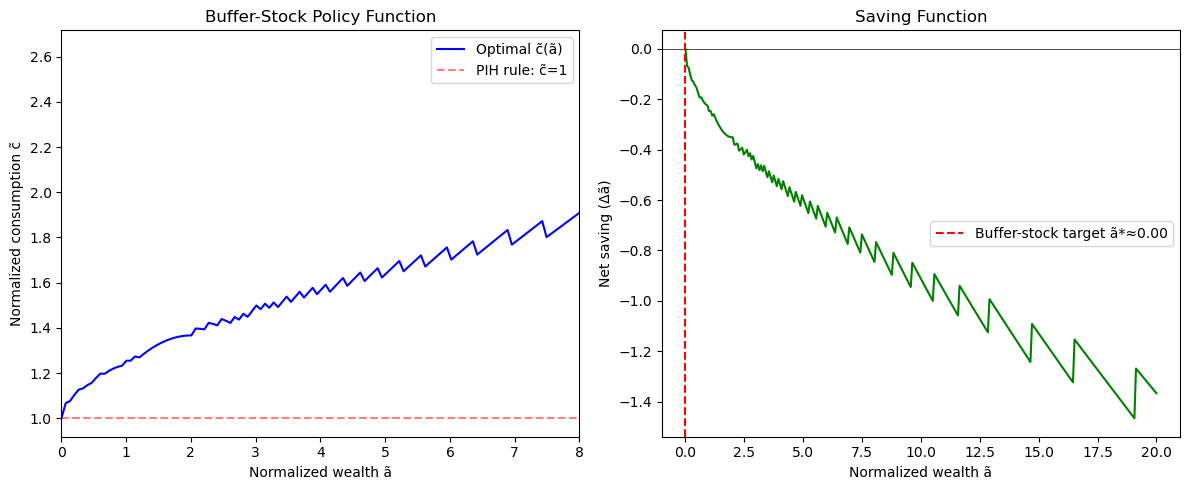

Buffer-stock target ã* ≈ 0.000


In [2]:
import numpy as np
from scipy.interpolate import interp1d

# Buffer-stock model: normalized variables (c_hat, a_hat = c/P, a/P)
beta, r, G, sigma = 0.96, 0.04, 1.03, 2.0
beta_tilde = beta * G**(1-sigma)  # effective discount in normalized problem
print(f"β̃ = {beta_tilde:.4f}  (< 1 iff impatient: {beta_tilde < 1})")

# Wealth grid (normalized by permanent income)
N = 300
a_min, a_max = 0.0, 20.0
a_grid = np.linspace(a_min, a_max, N)

# Income shocks: discrete approximation (simplified 3-state)
y_vals = np.array([0.6, 1.0, 1.4])   # transitory shocks
y_probs = np.array([0.25, 0.50, 0.25])

# CRRA utility
def u(c): return c**(1-sigma)/(1-sigma) if sigma != 1 else np.log(c)
def u_vec(c): return np.where(c > 1e-10, c**(1-sigma)/(1-sigma), -1e20)

# Value Function Iteration
def bellman_operator(V_in, a_grid, y_vals, y_probs, beta_t, r):
    N = len(a_grid)
    V_new = np.zeros(N)
    c_opt = np.zeros(N)
    V_interp = interp1d(a_grid, V_in, kind='linear', fill_value='extrapolate')
    
    for i, a in enumerate(a_grid):
        # Cash-on-hand: a + y for each income realization
        # Here: use average income for simplicity (full model uses expectation)
        y_avg = np.dot(y_vals, y_probs)
        x = a + y_avg  # cash on hand
        
        # Feasible consumption: c in [ε, x]
        c_choices = np.linspace(1e-6, x, 100)
        a_next = (1+r) * (x - c_choices) / G  # next period normalized wealth
        a_next = np.maximum(a_next, a_min)     # borrowing constraint
        
        EV_next = V_interp(a_next)
        payoffs = u_vec(c_choices) + beta_t * EV_next
        idx_opt = np.argmax(payoffs)
        V_new[i] = payoffs[idx_opt]
        c_opt[i] = c_choices[idx_opt]
    
    return V_new, c_opt

# Initialize and iterate
V = np.log(np.maximum(a_grid, 0.1)) / (1-sigma)  # initial guess
for iteration in range(500):
    V_new, c_opt = bellman_operator(V, a_grid, y_vals, y_probs, beta_tilde, r)
    diff = np.max(np.abs(V_new - V))
    V = V_new
    if diff < 1e-6:
        print(f"Converged in {iteration+1} iterations, final diff = {diff:.2e}")
        break

# Buffer stock target: where savings = 0 (c_opt(a) = a + y_avg - a)
import matplotlib.pyplot as plt
y_avg = np.dot(y_vals, y_probs)
savings = (a_grid + y_avg - c_opt) * (1+r)/G - a_grid  # net change in wealth

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(a_grid, c_opt, 'b-', label='Optimal c̃(ã)')
ax1.plot(a_grid, np.ones_like(a_grid), 'r--', alpha=0.5, label='PIH rule: c̃=1')
ax1.set_xlabel('Normalized wealth ã'); ax1.set_ylabel('Normalized consumption c̃')
ax1.set_title('Buffer-Stock Policy Function'); ax1.legend(); ax1.set_xlim(0, 8)

ax2.plot(a_grid, savings, 'g-')
ax2.axhline(0, color='black', linewidth=0.5)
bs_target_idx = np.argmin(np.abs(savings))
ax2.axvline(a_grid[bs_target_idx], color='red', linestyle='--', 
            label=f'Buffer-stock target ã*≈{a_grid[bs_target_idx]:.2f}')
ax2.set_xlabel('Normalized wealth ã'); ax2.set_ylabel('Net saving (Δã)')
ax2.set_title('Saving Function'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"Buffer-stock target ã* ≈ {a_grid[bs_target_idx]:.3f}")

### Julia

```julia
using Interpolations

beta, r, G, sigma = 0.96, 0.04, 1.03, 2.0
beta_t = beta * G^(1-sigma)
N = 200
a_grid = range(0.0, 20.0, length=N) |> collect
u(c) = c > 1e-10 ? c^(1-sigma)/(1-sigma) : -1e20

function bellman!(V_new, c_new, V, a_grid, beta_t, r, G)
    itp = LinearInterpolation(a_grid, V, extrapolation_bc=Line())
    y_avg = 1.0  # simplified: average income = 1
    for (i, a) in enumerate(a_grid)
        x = a + y_avg
        c_grid = range(1e-6, x, length=150)
        a_next = max.((1+r).*(x .- c_grid)./G, 0.0)
        payoffs = u.(c_grid) .+ beta_t .* itp.(a_next)
        idx = argmax(payoffs)
        V_new[i] = payoffs[idx]; c_new[i] = c_grid[idx]
    end
end

V = log.(max.(a_grid, 0.1)) ./ (1-sigma)
V_new = similar(V); c_new = similar(V)
for iter in 1:500
    bellman!(V_new, c_new, V, a_grid, beta_t, r, G)
    diff = maximum(abs.(V_new .- V)); V .= V_new
    if diff < 1e-6
        println("Converged in $iter iterations"); break
    end
end
println("Policy at ã=1: c̃=$(round(c_new[findfirst(a_grid .>= 1.0)], digits=3))")
```

### R

```r
beta <- 0.96; r <- 0.04; G <- 1.03; sigma <- 2.0
beta_t <- beta * G^(1-sigma)
N <- 150
a_grid <- seq(0, 15, length.out=N)
u <- function(c) ifelse(c > 1e-10, c^(1-sigma)/(1-sigma), -1e20)

bellman_step <- function(V) {
  V_new <- numeric(N); c_opt <- numeric(N)
  V_itp <- approxfun(a_grid, V, rule=2)
  for(i in seq_len(N)) {
    x <- a_grid[i] + 1.0  # cash on hand (income=1)
    cs <- seq(1e-6, x, length.out=100)
    a_next <- pmax((1+r)*(x-cs)/G, 0)
    payoffs <- u(cs) + beta_t * V_itp(a_next)
    idx <- which.max(payoffs)
    V_new[i] <- payoffs[idx]; c_opt[i] <- cs[idx]
  }
  list(V=V_new, c=c_opt)
}

V <- log(pmax(a_grid, 0.1))/(1-sigma)
for(iter in 1:500) {
  res <- bellman_step(V)
  diff <- max(abs(res$V - V)); V <- res$V
  if(diff < 1e-6) { cat(sprintf("Converged in %d iters\n", iter)); break }
}
cat(sprintf("Policy at ã=2: c̃=%.3f (PIH would give 1.0)\n",
            res$c[which.min(abs(a_grid-2))]))
```

---

## 15.7 Programming Exercises

### Exercise 15.1 (APL — VFI with Convergence Criterion)

Implement the full VFI loop in APL using `⍣` with a convergence guard: `V_star ← bellman ⍣ converged ⊢ V0` where `converged ← {1e¯6 > ⌈/|⍺-⍵}` compares consecutive iterates. Test on the deterministic consumption-saving problem with $\beta = 0.96$, $r = 0.04$, CRRA $\sigma = 2$, grid of 100 points on $[0.01, 10]$. Compare the APL policy function to the analytical certainty-equivalent solution $c^*(a) = (1-\beta(1+r)^{1-1/\sigma})a$ (which holds exactly for CRRA with no borrowing constraint and constant return).

### Exercise 15.2 (Python — Howard Improvement Speed Comparison)

Implement both VFI and Howard PFI for the simple deterministic problem of Exercise 15.1. Measure the number of Bellman operator evaluations to reach $\varepsilon = 10^{-8}$ precision for each method. Plot the convergence path $\|V^n - V^*\|_\infty$ vs. iteration count for both. How many times faster is PFI than VFI? Does the speedup match the theoretical prediction?

### Exercise 15.3 (Julia — Stochastic Income)

```julia
# Full buffer-stock model with Tauchen-discretized income process
using Distributions
function tauchen(rho, sigma_eps, N, m=3)
    sigma_z = sigma_eps / sqrt(1-rho^2)
    z = range(-m*sigma_z, m*sigma_z, length=N)
    dz = step(z); d = Normal(0, sigma_eps)
    P = zeros(N,N)
    for i=1:N
        mu = rho*z[i]
        P[i,1] = cdf(d, z[1]+dz/2-mu)
        P[i,N] = 1-cdf(d,z[N]-dz/2-mu)
        for j=2:N-1; P[i,j]=cdf(d,z[j]+dz/2-mu)-cdf(d,z[j]-dz/2-mu); end
    end
    exp.(z), P  # income levels and transition matrix
end

y_grid, Pi = tauchen(0.95, 0.1, 5)
println("Income grid: ", round.(y_grid, digits=3))
println("Transition matrix row sums: ", sum(Pi, dims=2))
```

Extend the VFI from Section 15.6 to use this income process. Compute: (a) the optimal policy function $c^*(a, y)$ for each $(a, y)$ combination; (b) the stationary wealth distribution by simulating the model for 10,000 periods; (c) the aggregate MPC (average over the wealth distribution).

### Exercise 15.4 — Endogenous Grid Method ($\star$)

The **endogenous grid method** (Carroll, 2006) dramatically speeds up VFI by inverting the Euler equation rather than searching over the grid. For CRRA utility, the Euler equation gives: $c_t^{-\sigma} = \beta(1+r)\mathbb{E}_t[c_{t+1}^{-\sigma}]$, so $c_t = [\beta(1+r)\mathbb{E}_t[c_{t+1}^{-\sigma}]]^{-1/\sigma}$. (a) Implement the EGM: start with a grid of $a_{t+1}$ values, compute the implied $c_{t+1}$ from the next period's policy, compute $c_t$ from the Euler equation, and recover $a_t = c_t + a_{t+1}/(1+r)$. (b) Compare the number of function evaluations to achieve the same precision as VFI. (c) Extend to include a borrowing constraint: EGM handles this through kinking.

---

## 15.8 Chapter Summary

**Key results:**

- **Bellman's principle of optimality** converts an infinite-sequence optimization into a functional equation $V = \mathcal{T}V$ — the Bellman equation.
- The **Bellman operator** $\mathcal{T}$ satisfies Blackwell's conditions (monotonicity and discounting) and is therefore a contraction with modulus $\beta < 1$ on the space of bounded continuous functions.
- The **Banach fixed-point theorem** guarantees: (1) a unique fixed point $V^*$; (2) VFI converges from any $V_0$ with error bound $\beta^n/(1-\beta)\cdot\|V_1-V_0\|$.
- **VFI Algorithm:** initialize $V^0$; repeatedly apply $\mathcal{T}$: $V^{n+1}(a_i) = \max_c\{u(c)+\beta V^n(a')\}$; stop when $\|V^{n+1}-V^n\|_\infty < \varepsilon$.
- **Howard PFI** converges in $\sim10$–20 iterations by alternating policy evaluation (solving a linear system) with policy improvement (one step of VFI).
- **Buffer-stock model**: impatient households ($\tilde\beta < 1$) with borrowing constraints and income uncertainty maintain a target wealth-income ratio $\hat{a}^*$; the policy function is concave and approaches the PIH linear rule at high wealth.
- In APL: the Bellman operator is `⌈⌿ u_mat + beta × V_next_mat` — column-wise max of the payoff matrix; convergence is `bellman ⍣ (1e¯6∘>⌈/|⊢-bellman) ⊢ V0`.

*Next: Chapter 16 — The Discrete-Time Overlapping Generations Model*